# Preparação dos Dados
- Separar os dados em Teste e Treino
- Fazer a Normalização via *Min-Max Scaller*

In [27]:
import pandas as pd

# Definir conforme a necessidade
caminho = '../'

df = pd.read_csv(caminho + 'database/processed/CBCovid19_Tratado.csv')

In [28]:
print(df['pcr'].value_counts())
print(pd.DataFrame([0 if tipo == 'negative' else 1 for tipo in df['pcr']]).value_counts())

pcr
negative    248
positive    121
Name: count, dtype: int64
0
0    248
1    121
Name: count, dtype: int64


In [29]:
df.columns

Index(['age', 'leukocytes', 'neutrophilsP', 'lymphocytesP', 'monocytesP',
       'eosinophilsP', 'basophilsP', 'neutrophils', 'lymphocytes', 'monocytes',
       'eosinophils', 'basophils', 'redbloodcells', 'mcv', 'mch', 'mchc',
       'rdwP', 'hemoglobin', 'hematocritP', 'platelets', 'mpv', 'pcr',
       'sex_bin'],
      dtype='str')

In [30]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['pcr'])
y = df['pcr'].map({'negative': 0, 'positive': 1})

# Separar em Teste e Treino (60/40)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=14, stratify=y
)

In [31]:
X_train.columns

Index(['age', 'leukocytes', 'neutrophilsP', 'lymphocytesP', 'monocytesP',
       'eosinophilsP', 'basophilsP', 'neutrophils', 'lymphocytes', 'monocytes',
       'eosinophils', 'basophils', 'redbloodcells', 'mcv', 'mch', 'mchc',
       'rdwP', 'hemoglobin', 'hematocritP', 'platelets', 'mpv', 'sex_bin'],
      dtype='str')

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
# Normalizar os dados

# scaler = MinMaxScaler()
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)

In [33]:
X_test_scaled.columns

Index(['age', 'leukocytes', 'neutrophilsP', 'lymphocytesP', 'monocytesP',
       'eosinophilsP', 'basophilsP', 'neutrophils', 'lymphocytes', 'monocytes',
       'eosinophils', 'basophils', 'redbloodcells', 'mcv', 'mch', 'mchc',
       'rdwP', 'hemoglobin', 'hematocritP', 'platelets', 'mpv', 'sex_bin'],
      dtype='str')

In [34]:
y_test.shape

(148,)

In [35]:
# Salvar em csv

X_train_scaled.to_csv(caminho + 'database/processed/splitted/X_train.csv', index=False)
X_test_scaled.to_csv(caminho + 'database/processed/splitted/X_test.csv', index=False)
y_train.to_csv(caminho + 'database/processed/splitted/y_train.csv', index=False)
y_test.to_csv(caminho + 'database/processed/splitted/y_test.csv', index=False)

## PCA

In [36]:
qtd_colunas_completo = len(X_test_scaled.columns)
print(f"Número de colunas totais: {qtd_colunas_completo}")

Número de colunas totais: 22


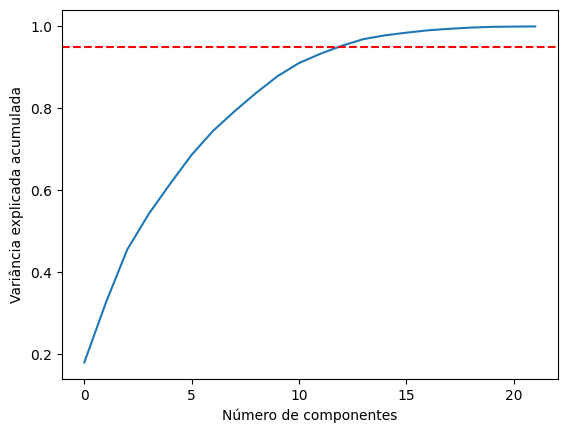

In [37]:
import numpy as np
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt

pca_full = PCA().fit(X_train_scaled)
var_acumulada = np.cumsum(pca_full.explained_variance_ratio_)

plt.plot(var_acumulada)
plt.xlabel('Número de componentes')
plt.ylabel('Variância explicada acumulada')
plt.axhline(y=0.95, color='r', linestyle='--')
plt.show()

In [38]:
# Usar 10 componentes (aproximadamente 95% de explicabilidade)
pca = PCA(n_components=10)  

X_train_scaled_pca = pca.fit_transform(X_train_scaled)
X_test_scaled_pca  = pca.transform(X_test_scaled)

In [39]:
import pandas as pd

# Criar nomes de colunas para os componentes
colunas_pca = [f'PC{i+1}' for i in range(pca.n_components_)]

X_train_scaled_pca = pd.DataFrame(X_train_scaled_pca, columns=colunas_pca)
X_test_scaled_pca = pd.DataFrame(X_test_scaled_pca, columns=colunas_pca)

X_train_scaled_pca.to_csv(caminho + 'database/processed/splitted/X_train_pca.csv', index=False)
X_test_scaled_pca.to_csv(caminho + 'database/processed/splitted/X_test_pca.csv', index=False)

## Entendendo algumas Features do Modelo

### Dicionário de Features do Hemograma

#### Série Branca (Leucograma - Imunidade / Inflamação)
* **`leukocytes`**: Leucócitos Totais (/mm³) — Glóbulos brancos totais.
* **`neutrophilsP`**: Neutrófilos Percentuais (%) — Proporção de neutrófilos.
* **`neutrophils`**: Neutrófilos Absolutos (/mm³) — Resposta contra infecções bacterianas.
* **`lymphocytesP`**: Linfócitos Percentuais (%) — Proporção de linfócitos.
* **`lymphocytes`**: Linfócitos Absolutos (/mm³) — Imunidade adaptativa e viral.
* **`monocytesP`**: Monócitos Percentuais (%) — Proporção de monócitos.
* **`monocytes`**: Monócitos Absolutos (/mm³) — Fagocitose e infecções crônicas.
* **`eosinophilsP`**: Eosinófilos Percentuais (%) — Proporção de eosinófilos.
* **`eosinophils`**: Eosinófilos Absolutos (/mm³) — Alergias e parasitoses.
* **`basophilsP`**: Basófilos Percentuais (%) — Proporção de basófilos.
* **`basophils`**: Basófilos Absolutos (/mm³) — Liberação de histamina/reações alérgicas.

#### Série Vermelha (Eritrograma - Oxigenação / Anemias)
* **`redbloodcells`**: Hemácias/Eritrócitos (milhões/mm³) — Glóbulos vermelhos totais.
* **`hemoglobin`**: Hemoglobina (g/dL) — Proteína carreadora de oxigênio.
* **`hematocritP`**: Hematócrito (%) — Porcentagem do sangue ocupada por hemácias.
* **`mcv`**: VCM (fL) — Volume Corpuscular Médio (tamanho da hemácia).
* **`mch`**: HCM (pg) — Hemoglobina Corpuscular Média (peso de Hb por hemácia).
* **`mchc`**: CHCM (g/dL) — Concentração de Hb Corpuscular Média.
* **`rdwP`**: RDW (%) — Amplitude de Distribuição das Hemácias (variação de tamanho).

#### Série Plaquetária (Hemostasia / Coagulação)
* **`platelets`**: Plaquetas (/mm³) — Contagem total de plaquetas.
* **`mpv`**: VPM (fL) — Volume Plaquetário Médio (tamanho/reatividade das plaquetas).